In [ ]:
# so, we are tying to build an intelligent program that solves the tasks in ARC that is hasn't seen before
# [[5]] --> [[5]]
# [[5]] --> [[10]]
# [[5]] --> 0
# can your intelligent program solve these tasks? 

In [1]:
# 2459 lines, 39 solved, 12 passed_some_traininputs, 8 passed_all_traininputs
from inductive_core_knowledge import * 
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'training'
tt = load_set(training_path)
known = load_serialized('assets/solved_indices_for_the_day.pkl')
this_task = Inductive(tt[343])

TypeError: object of type 'int' has no len()

In [1]:
from taskManagerV02 import *

In [2]:
from pathlib import Path
data_path = Path('/Users/hassanshallal/Desktop/abstract_reasoning_dataset/abstraction-and-reasoning-challenge/')
training_path = data_path / 'training'
tt = load_set(training_path)

In [ ]:
# can a program understand this structure of a dict of dict, list of list of list, set operations, does a program
# understand this?

In [ ]:
# Operators:
# bool: True, False
# Arithmetic Operators: +, -, *, /, %, ^, //
# Comparison Operators: ==, !=, <, >, <=, >=
# Assignment Operators: =, +=, -=, *=, /=, %=, **=, //=
# Bitwise operators: &, |, ^, ~, <<, >>
# logical operators: and, or, not
# membership: in, not in
# identity: is, is not
# precedence: **, ~ + - (Complement, unary plus and minus ), * / % // (Multiply, divide, modulo and floor division),
#             + - (Addition and subtraction), >> << (Right and left bitwise shift), & (Bitwise 'AND'), 
#             ^ | (Bitwise exclusive `OR' and regular `OR'), <= < > >= (Comparison operators),
#             <> == != (Equality operators), = %= /= //= -= += *= **= (Assignment operators), 
#             is is not (Identity operators), in not in (Membership operators), not or and (Logical operators)

# abs(), int(), divmod(x, y) --> (x // y, x % y)
# data members, structures
# strings, lists, tuples: x in s, x not in s, len(s), range(x), s.reverse(),  
#                         min(s), max(s), s.index(x), s.count(x), sorted(s)
# Sets: len(s), x in s, x not in s, s.issubset(t) or (s <= t), s.issuperset(t) or (s >= t), s.union(t) or (s|t), 
#                                   s.intersection(t) or (s&t), s.difference(t) or (s - t), s.symmetric_difference(t) or (s^t)
# The elements of a set must be hashable. To represent sets of sets, the inner sets must be frozenset objects.
# Dicts: len(d), d.keys(), d.values(), d.items(), key in d, key not in d, 
# Initializations:
# >>> a = dict(one=1, two=2, three=3)
# >>> b = {'one': 1, 'two': 2, 'three': 3}
# >>> c = dict(zip(['one', 'two', 'three'], [1, 2, 3]))
# >>> d = dict([('two', 2), ('one', 1), ('three', 3)])
# >>> e = dict({'three': 3, 'one': 1, 'two': 2})
# >>> a == b == c == d == e
# True

# Unless your program knows how to use the above independently of you, it will be useless


In [25]:
# print_list.py
my_list = [1, 2, 3]
print(my_list, *my_list) # notice the unpacking of a list
# extract_list_body.py
my_list = [1, 2, 3, 4, 5, 6]

a, *b, c = my_list

print(a)
print(b)
print(c)

my_first_list = [1, 2, 3]
my_second_list = [4, 5, 6]
my_merged_list = [*my_first_list, *my_second_list]

print(my_merged_list)

# merging_dicts.py
my_first_dict = {"A": 1, "B": 2}
my_second_dict = {"C": 3, "D": 4}
my_merged_dict = {**my_first_dict, **my_second_dict}

print(my_merged_dict)

a = [*"RealPython"]
print(a)

[1, 2, 3] 1 2 3
1
[2, 3, 4, 5]
6
[1, 2, 3, 4, 5, 6]
{'A': 1, 'B': 2, 'C': 3, 'D': 4}
['R', 'e', 'a', 'l', 'P', 'y', 't', 'h', 'o', 'n']


In [42]:
z = set()
z.add('m')
z.add('a')

In [43]:
a = sorted([*z])
print(a)

['a', 'm']


In [19]:
#  a single asterisk (*) to unpack iterables
#  two asterisks (**) to unpack dictionaries
def isPrimitive(obj):
    return type(obj) in [int, float, bool, str, type(None)]

def is_container(obj):
    return type(obj) in [list, tuple, set, frozenset, dict]

In [288]:
# This is linear realization, we need non linear realization over consistent no mixed types concolved data
# structures

def realize_ds(*objects_):
    results = []
    key_sets = []
    for object_ in objects_:
        lenghts = []
        types = []
        while is_container(object_) and len(object_) > 0:
            lenghts.append(len(object_))
            types.append(type(object_))
            if type(object_) in [list, tuple]:
                object_ = object_[0] 
            elif type(object_) in [set, frozenset]:
                  object_ = object_.pop()
                  #think about the set
            elif type(object_) == dict:
                key_sets.append((object_.keys()))
                one_key = list(object_.keys())[0]
                object_ = (object_[one_key], one_key)
                
                
        lenghts.append(None)
        types.append(type(object_))
        results.append([lenghts, types])
        
    while len(results) == 1 and is_container(results):
         results = results[0]
    
    where_dicts = [i for i, x in enumerate(results[1]) if x == dict] # , [fix_dim(v).shape for v in object_.values()]
    # the len of where_dicts must equal the length of key_sets
    assert len(where_dicts) == len(key_sets)
    
    return results, key_sets

In [312]:
x = {'one':[[1], [2]], 'two':[[2, 4], [2, 4]]}

In [313]:
len(x), list(x.items())

(2, [('one', [[1], [2]]), ('two', [[2, 4], [2, 4]])])

In [289]:
realize_ds(tt[0])

([[2, 2, 1, 2, 2, 3, 3, None],
  [dict, tuple, list, dict, tuple, list, list, int]],
 [(dict_keys(['test', 'train']), [(1, 1), (5, 1)]),
  (dict_keys(['input', 'output']), [(3, 3), (9, 9)])])

In [291]:
realize_ds([[1, 2, 3], [4, 5, 6]])

([[2, 3, None], [list, list, int]], [])

In [292]:
x = set()
x.add(((1,2,3), 'nonbg'))
realize_ds(x)

([[1, 2, 3, None], [set, tuple, tuple, int]], [])

In [298]:
tuple([(1, 2, 3), (4, 5, 6)])

((1, 2, 3), (4, 5, 6))

In [299]:
realize_ds([(1, 2, 3), (4, 5, 6)])

([[2, 3, None], [list, tuple, int]], [])

In [6]:
def first_principles_operations(*args, **kwargs):
    if len(args) > 0 and len(kwargs) == 0:
        if all([is_container(arg) for arg in args]):
            
        pass
    elif len(kwargs) > 0 and len(args) == 0:
        pass
    elif len(args) > 0 and len(kwargs) > 0:
        pass
    else:
        return

In [ ]:
augmenting_tasks = []

In [ ]:
d1 = {}
d1['test'] = []
d1['train'] = []


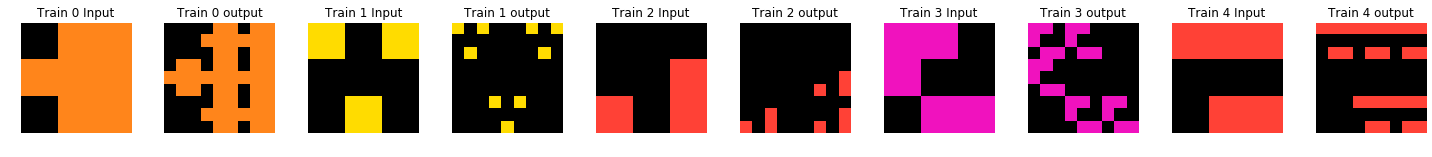

In [4]:
plot_task(tt[0])